# Thompson Sampling

## Importing the libraries

In [31]:
# ===========================================
# STEP 1: Importing the required libraries
# ===========================================
# We import the essential libraries for our project:
# 1. numpy    → for numerical operations, arrays, and calculations.
# 2. matplotlib.pyplot → for creating data visualizations.
# 3. pandas   → for reading CSV files and manipulating datasets.
# These are required for loading data, performing calculations,
# and visualizing results during the Thompson Sampling simulation.

# Step 1a: Import numpy for numerical operations
import numpy as np

# Step 1b: Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Step 1c: Import pandas for data manipulation and reading CSV files
import pandas as pd

## Importing the dataset

In [32]:
# ===========================================
# STEP 2: Importing the dataset
# ===========================================
# We load the dataset containing user interactions with ads.
# 1. Read the CSV file into a pandas DataFrame.
# 2. Optionally, inspect the first few rows to verify the data.

# Step 2a: Read the CSV file into a pandas DataFrame
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

# Step 2b: Display the first 5 rows to check the dataset
dataset.head()

,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0


## Implementing Thompson Sampling

In [33]:
# ===========================================
# STEP 3: THOMPSON SAMPLING ALGORITHM
# ===========================================

# =======================
# Step 3a: Import random library for Beta distribution sampling
# We need random.betavariate() to sample from the Beta distribution
# for each ad's estimated reward probability at each round.
# =======================
import random

# =======================
# Step 3b: Initialize variables for the Thompson Sampling algorithm
# We define the number of users, number of ads,
# and initialize lists and counters for selections and rewards.
# =======================

# Total number of users (rounds)
N = 10000

# Total number of ads
d = 10

# List to store the index of ad selected in each round
ads_selected = []

# List to count how many times each ad received reward 1 (clicked)
numbers_of_rewards_1 = [0] * d

# List to count how many times each ad received reward 0 (not clicked)
numbers_of_rewards_0 = [0] * d

# Variable to store the total reward accumulated
total_reward = 0

# =======================
# Step 3c: Run Thompson Sampling algorithm over all users
# For each user, sample a Beta distribution for each ad,
# select the ad with the highest sample, and update reward counters.
# =======================

for n in range(0, N):

    # Step 3c-i: Initialize the ad to be selected and max sample for this round
    ad = 0
    max_random = 0

    # Step 3c-ii: Loop over all ads to draw a Beta sample for each
    for i in range(0, d):

        # Step 3c-iii: Draw a random sample from the Beta distribution
        # Beta(alpha, beta) where:
        # alpha = numbers_of_rewards_1[i] + 1 (successes + 1)
        # beta  = numbers_of_rewards_0[i] + 1 (failures + 1)
        random_beta = random.betavariate(
            numbers_of_rewards_1[i] + 1,
            numbers_of_rewards_0[i] + 1
        )

        # Step 3c-iv: Select the ad with the highest Beta sample so far
        if random_beta > max_random:
            max_random = random_beta
            ad = i

    # =======================
    # Step 3d: Update counters after selecting the ad
    # =======================

    # Store the selected ad in the list
    ads_selected.append(ad)

    # Get the reward (0 or 1) for this ad from the dataset
    reward = dataset.values[n, ad]

    # Update reward counters based on the outcome
    if reward == 1:
        # Step 3d-i: Increment success counter for this ad
        numbers_of_rewards_1[ad] += 1
    else:
        # Step 3d-ii: Increment failure counter for this ad
        numbers_of_rewards_0[ad] += 1

    # Update the total reward accumulated
    total_reward += reward

## Visualising the results -

###Histogram

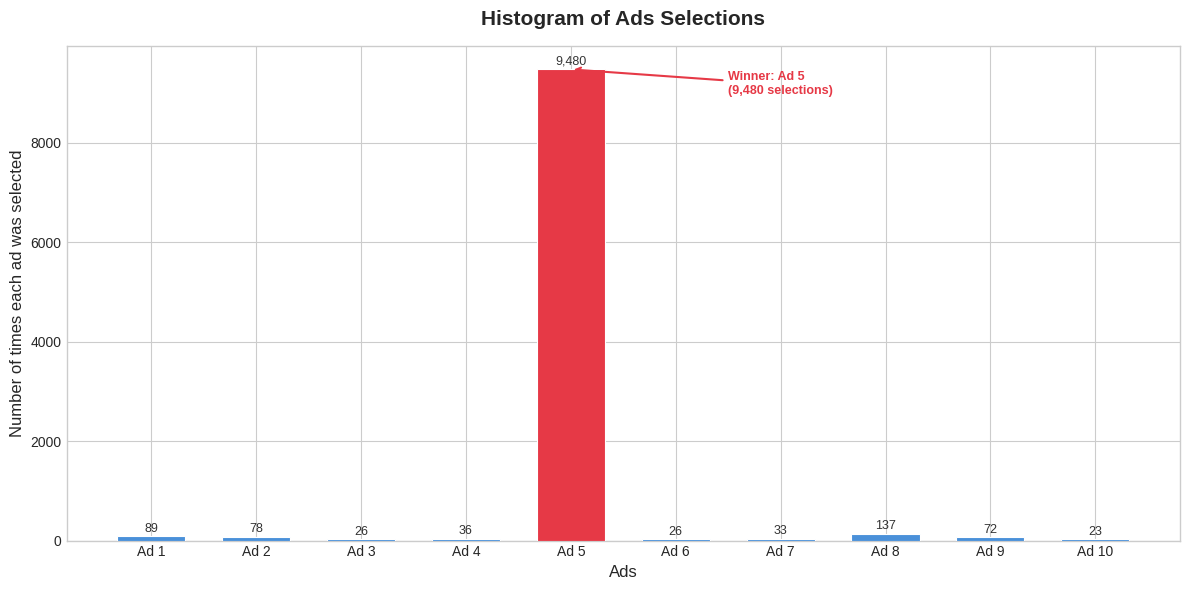

In [34]:
# ===========================================
# STEP 4: VISUALISING THE RESULTS - HISTOGRAM
# ===========================================
# We want to see which ads were selected the most over all rounds.
# A bar chart will show the frequency of selection for each ad.

# Step 4a: Import required libraries
import matplotlib.pyplot as plt
import numpy as np

# =======================
# Step 4b: Prepare the data
# Count how many times each ad was selected
# Shift ad indices from (0-9) to (1-10) for display
# =======================

# Count selections per ad using numpy
ad_counts = np.bincount(ads_selected, minlength=d)

# Ad labels from 1 to 10
ad_labels = [f'Ad {i+1}' for i in range(d)]

# Identify the winning ad (most selected)
winning_ad = np.argmax(ad_counts)

# Assign colors: red for winner, steelblue for others
colors = ['#E63946' if i == winning_ad else '#4A90D9' for i in range(d)]

# =======================
# Step 4c: Create the bar chart
# Using bar() instead of hist() gives us full control
# over colors, labels, and spacing per ad
# =======================

# Apply clean plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 6))

# Draw bars for each ad
bars = ax.bar(range(d), ad_counts, color=colors, edgecolor='white',
              linewidth=0.8, width=0.65, zorder=3)

# =======================
# Step 4d: Add value labels on top of each bar
# Shows exact selection count above each bar
# =======================

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # X center of bar
        height + 30,                           # Slightly above bar top
        f'{int(height):,}',                    # Formatted count with comma
        ha='center', va='bottom',
        fontsize=9, color='#333333'
    )

# =======================
# Step 4e: Add annotation arrow pointing to the winning ad
# =======================

# Annotate the winning bar with an arrow
ax.annotate(
    f'Winner: Ad {winning_ad + 1}\n({ad_counts[winning_ad]:,} selections)',
    xy=(winning_ad, ad_counts[winning_ad]),
    xytext=(winning_ad + 1.5, ad_counts[winning_ad] - 500),
    fontsize=9, color='#E63946', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#E63946', lw=1.5)
)

# =======================
# Step 4f: Final styling - title, labels, ticks, layout
# =======================

# Add title and axis labels
ax.set_title('Histogram of Ads Selections', fontsize=15,
             fontweight='bold', pad=15)
ax.set_xlabel('Ads', fontsize=12)
ax.set_ylabel('Number of times each ad was selected', fontsize=12)

# Set x-ticks to show Ad 1 → Ad 10
ax.set_xticks(range(d))
ax.set_xticklabels(ad_labels, fontsize=10)

# Step 4g: Display the final plot
plt.tight_layout()
plt.show()

###Cumulative Line Plot

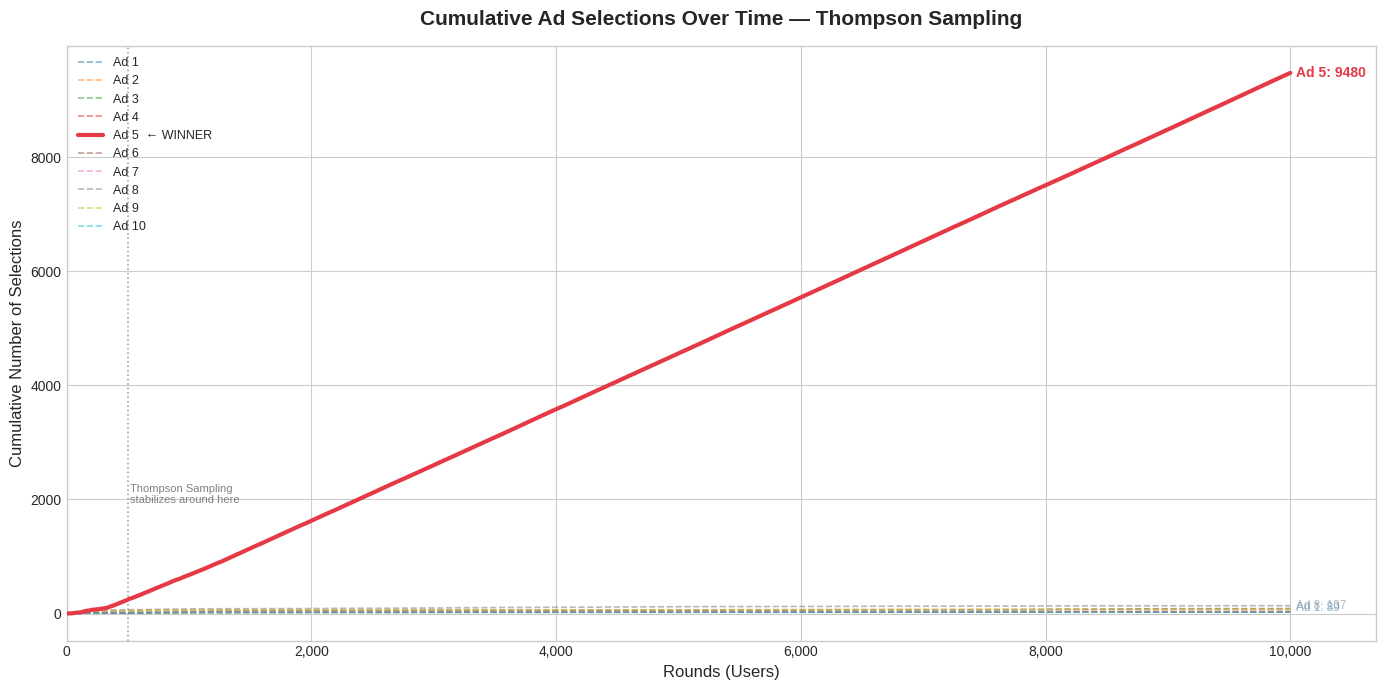

In [35]:
# ===========================================
# STEP 5: ADVANCED VISUALIZATION - CUMULATIVE LINE PLOT
# ===========================================
# Here we show how many times each ad was selected over all rounds.
# Each ad will have its own line showing cumulative selections.
# This gives insight into how Thompson Sampling learns over time.

# Step 5a: Import required libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# =======================
# Step 5b: Prepare cumulative data for plotting
# Create a 2D numpy array: shape (d x N)
# Each row i stores cumulative selections of ad i over N rounds
# =======================

# Initialize cumulative selections array with zeros
cumulative_selections = np.zeros((d, N), dtype=int)

# Fill cumulative selections round by round
for n in range(N):
    ad = ads_selected[n]           # Ad selected in this round
    for i in range(d):
        if n == 0:
            cumulative_selections[i][n] = 1 if i == ad else 0
        else:
            cumulative_selections[i][n] = cumulative_selections[i][n-1] + (1 if i == ad else 0)

# =======================
# Step 5c: Identify the winning ad (most selected overall)
# The winning ad is the one with the highest final cumulative count
# =======================

# Find the index of the winning ad
winning_ad = np.argmax(cumulative_selections[:, -1])

# =======================
# Step 5d: Define a clean color palette
# Use a colormap to assign a distinct color to each ad
# Winning ad gets a special highlight color
# =======================

# Generate distinct colors for each ad using tab10 colormap
colors = plt.cm.tab10(np.linspace(0, 1, d))

# =======================
# Step 5e: Plot setup - style and figure size
# Use a clean whitegrid style for better readability
# =======================

# Apply clean plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 7))

# =======================
# Step 5f: Define which ads get end-of-line labels
# Only show labels for Ad 1, Ad 5, Ad 8 (the well-separated lines)
# All other ads are too close together and would cause overlapping labels
# =======================

# Ads that get end-of-line annotations (0-indexed: 0=Ad1, 4=Ad5, 7=Ad8)
labeled_ads = {0, 4, 7}

# =======================
# Step 5g: Plot each ad's cumulative selection line
# Winning ad gets thicker line + special color + end label
# All other ads get thinner lines with slight transparency
# =======================

for i in range(d):

    # Check if this is the winning ad
    is_winner = (i == winning_ad)

    # Set line properties based on whether this ad is the winner
    lw        = 3.0 if is_winner else 1.2        # Line width
    alpha     = 1.0 if is_winner else 0.55        # Transparency
    color     = '#E63946' if is_winner else colors[i]  # Red for winner
    zorder    = 5 if is_winner else 2             # Draw winner on top
    linestyle = '-' if is_winner else '--'        # Solid for winner

    # Plot the cumulative line for ad i
    ax.plot(
        range(N),
        cumulative_selections[i],
        color=color,
        linewidth=lw,
        alpha=alpha,
        zorder=zorder,
        linestyle=linestyle,
        label=f'Ad {i+1}{"  ← WINNER" if is_winner else ""}'
    )

    # Step 5h: Add end-of-line label only for well-separated ads
    if i in labeled_ads:
        final_count = cumulative_selections[i, -1]
        ax.annotate(
            f'Ad {i+1}: {final_count}',
            xy=(N - 1, final_count),
            xytext=(N + 50, final_count),
            fontsize=8.5 if not is_winner else 10,
            color=color,
            alpha=alpha,
            fontweight='bold' if is_winner else 'normal',
            va='center'
        )

# =======================
# Step 5i: Add a vertical annotation marking Thompson Sampling convergence zone
# Thompson Sampling typically converges faster than UCB
# Place the text at a fixed low y-position to avoid overlapping end-labels
# =======================

# Draw a dashed vertical line at round 500 (convergence point)
ax.axvline(x=500, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)

# Use a fixed low y-position (20% of max) to keep text away from end-labels
max_selections = cumulative_selections.max()
ax.text(520, max_selections * 0.20,
        'Thompson Sampling\nstabilizes around here',
        fontsize=8, color='gray', va='bottom')

# =======================
# Step 5j: Final styling - title, labels, legend, layout
# =======================

# Add title and axis labels
ax.set_title('Cumulative Ad Selections Over Time — Thompson Sampling',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Rounds (Users)', fontsize=12)
ax.set_ylabel('Cumulative Number of Selections', fontsize=12)

# Format x-axis with comma separators for readability
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add legend inside the plot (upper left)
ax.legend(loc='upper left', fontsize=9, framealpha=0.85)

# Extend x-axis slightly to fit end-of-line labels
ax.set_xlim(0, N + 700)

# Tight layout for clean spacing
plt.tight_layout()

# Step 5k: Display the final plot
plt.show()